# Objetivo do experimento
O objetivo deste experimento é avaliar o comportamento inicial do Algoritmo Genético (GA) aplicado à otimização de hiperparâmetros de uma rede neural MLP, utilizando uma configuração com mais diversidade.

Busca-se observar:

Convergência do algoritmo

Estabilidade do fitness ao longo das gerações

Capacidade de exploração do espaço de busca

## Configuração do Algoritmo Genético

A configuração adotada neste experimento foi:

Experimento 3 – exploratório/agressivo

Tamanho da população: 15

Gerações: 20

Taxa de mutação: 0.25

Taxa de cruzamento: 0.9

Elitismo: 1

Tamanho de torneio: 3

## Justificativa das escolhas:

Population size = 15
Valor aumentado para ampliar a diversidade genética da população, permitindo uma exploração mais abrangente do espaço de hiperparâmetros, mesmo com maior custo computacional.

Elitismo = 1
Mantém a melhor solução encontrada em cada geração, evitando regressão de desempenho, ao mesmo tempo em que permite maior liberdade exploratória para o restante da população.

Tournament size = 3
Aumenta a pressão seletiva em relação ao experimento 1, favorecendo indivíduos com melhor desempenho, mas ainda preservando diversidade genética.

Crossover rate = 0.9
Alta taxa de cruzamento para intensificar a recombinação genética entre indivíduos, acelerando a propagação de boas características na população.

Mutation rate = 0.25
Taxa de mutação elevada com o objetivo de aumentar a exploração do espaço de busca e reduzir o risco de convergência prematura.

Random seed = 42
Permite reprodutibilidade dos resultados.

## Execução do experimento

In [1]:
from fase_2.ga.ga_runner import run_ga

HYPERPARAM_SPACE_EXP3 = {

    "n_hidden_layers": [1, 2, 3],
    "n_neurons": [16, 32, 64, 128],
    "learning_rate_init": [0.0005, 0.001, 0.01],
    "activation": ["relu", "tanh"]
}

config_exp3 = {
    "population_size": 15,
    "generations": 20,
    "elite_size": 1,
    "tournament_size": 3,
    "crossover_rate": 0.9,
    "mutation_rate": 0.25,
    "random_seed": 42,
    "hyperparam_space": HYPERPARAM_SPACE_EXP3
}

result = run_ga(config_exp3)
result

/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/util

{'best_fitness': 0.7239819004524887,
 'best_individual': {'n_hidden_layers': 2,
  'n_neurons': 32,
  'learning_rate_init': 0.01,
  'activation': 'relu'},
 'fitness_history': [0.7237219988512349,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887,
  0.7239819004524887]}

## Resultados obtidos

Melhor indivíduo encontrado

In [2]:
result["best_individual"]

{'n_hidden_layers': 2,
 'n_neurons': 32,
 'learning_rate_init': 0.01,
 'activation': 'relu'}

## Melhor valor de fitness (F1-score)

In [3]:
result["best_fitness"]

0.7239819004524887

## Evolução do fitness ao longo das gerações

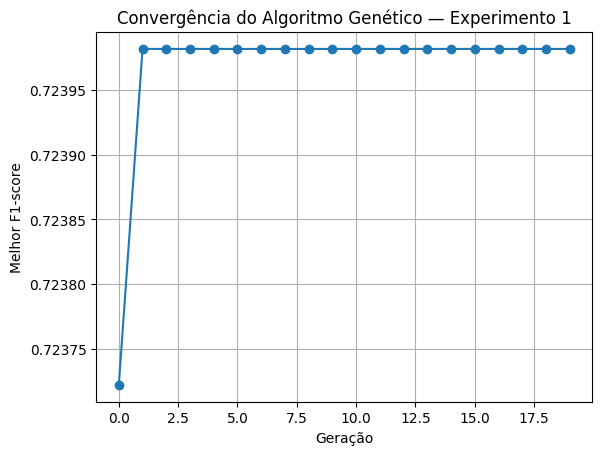

In [4]:
import matplotlib.pyplot as plt

plt.plot(result["fitness_history"], marker='o')
plt.xlabel("Geração")
plt.ylabel("Melhor F1-score")
plt.title("Convergência do Algoritmo Genético — Experimento 1")
plt.grid(True)
plt.show()

## Análise dos resultados

Apesar do aumento do espaço de busca e do tempo computacional no Experimento 2, o ganho em F1-score foi marginal (≈ 0.3%) quando comparado ao Experimento 1.
Esse comportamento indica que o modelo MLP treinado na Fase 1 já se encontrava próximo de um ótimo local para o conjunto de dados analisado.
O aumento da exploração promovido pelo Algoritmo Genético não resultou em melhorias proporcionais, sugerindo limitação intrínseca do modelo ou dos dados.

## Comparativo com o modelo treinado sem otimização (Tech challenge fase 1)

In [5]:
from utils.module_diabetes import load_dataset, prepare_dataset, train_mlp
from fase_2.ga.fitness import calculate_fitness

baseline_params = {
    "hidden_layer_sizes": (16, 8)
}

df = load_dataset()
df_processed = prepare_dataset(df)
model, X_val, y_val = train_mlp(df_processed, baseline_params)
baseline_f1 = calculate_fitness(model, X_val, y_val)

baseline_f1

/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.7164351851851852

In [8]:
import pandas as pd

pd.DataFrame({
    "Modelo": ["Baseline", "GA - Experimento 3"],
    "F1-score": [baseline_f1, result["best_fitness"]]
})


,Modelo,F1-score
0,Baseline,0.716435
1,GA - Experimento 3,0.723982


## Conclusão do experimento 3

Comparando os resultados obtidos pelo Algoritmo Genético no Experimento 3 com os resultados dos Experimentos 1 e 2, bem como com o modelo treinado na Fase 1, observa-se que o F1-score da classe positiva permaneceu praticamente estável, atingindo aproximadamente 0.724.

Mesmo com a ampliação do espaço de busca dos hiperparâmetros — incluindo arquiteturas mais profundas, maior número de neurônios e taxas de mutação mais elevadas — o ganho de desempenho foi marginal quando comparado aos experimentos anteriores. Além disso, esse pequeno incremento ocorreu à custa de um aumento significativo do custo computacional, com tempo de execução consideravelmente superior ao observado no Experimento 1 e próximo ao do Experimento 2.

Esse comportamento indica que, apesar da abordagem mais agressiva e exploratória adotada no Experimento 3, o Algoritmo Genético encontrou limitações no espaço de busca dos hiperparâmetros da MLP, sugerindo que o modelo já se encontrava próximo de um ótimo local para o conjunto de dados analisado.

O Experimento 3 demonstra que:

A ampliação do espaço de busca e o aumento da diversidade genética não garantem ganhos proporcionais de desempenho;

O Algoritmo Genético é capaz de explorar arquiteturas mais complexas, porém apresenta retornos decrescentes quando aplicado a um modelo já bem ajustado;

O custo computacional cresce de forma significativa à medida que se aumenta a exploração, sem necessariamente resultar em melhorias relevantes no desempenho.

Os resultados obtidos reforçam a importância de avaliar cuidadosamente o trade-off entre desempenho e custo computacional, além de evidenciar que, para o problema analisado, abordagens excessivamente exploratórias tendem a atingir rapidamente um platô de desempenho. Assim, o Experimento 3 contribui para a compreensão dos limites práticos de otimização do Algoritmo Genético aplicado à MLP, encerrando a análise experimental com uma visão clara sobre eficiência, estabilidade e convergência do método.